# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Ahmad Nurus Sholihin
- Email: ansstatistika295@gmail.com
- Id Dicoding: ahmad_nurus_sholihin

## Persiapan

> Tahap ini menyiapkan lingkungan kerja proyek agar proses analisis, pemodelan, dan evaluasi berjalan konsisten.

Yang dilakukan pada tahap ini:
- Import library untuk data processing, visualisasi, dan machine learning.
- Menentukan sumber data dan memastikan data dapat diakses.

Output tahap persiapan:
- Seluruh dependensi siap dipakai.
- Dataset awal berhasil dimuat ke DataFrame untuk proses berikutnya.

### Menyiapkan Library yang Dibutuhkan

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
print('lanjut')

lanjut


### Menyiapkan Data yang Akan Digunakan

> Data diambil dari sumber publik Dicoding, kemudian dibaca dengan delimiter `;` agar struktur kolom sesuai.

Langkah pada sel berikut:
- Mengambil data dari URL.
- Membaca data ke DataFrame.
- Menyimpan salinan ke format Excel untuk kebutuhan dashboard.

Output:
- DataFrame `df` siap digunakan untuk Data Understanding.
- File Excel untuk pembutan dasboard

In [2]:
DATA_URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"

df = pd.read_csv(DATA_URL, sep=";")

# download data ke excel untuk pembuatan dasboard
df.to_excel("students_performance.xlsx", index=False)
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

> Tahap ini bertujuan memahami karakteristik data dan mengidentifikasi faktor yang berkaitan dengan risiko dropout mahasiswa.

Cakupan analisis:
- Struktur data (tipe data, jumlah observasi, dan ringkasan awal).
- Kualitas data (missing value dan duplikasi).
- Analisis univariat (numerikal dan kategorikal).
- Analisis multivariat untuk melihat hubungan antar fitur dan target dropout.

Output utama:
- Insight awal untuk menentukan fitur yang relevan pada tahap preprocessing dan modeling.

In [3]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Missing value analysis
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_values = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

print("Missing value per kolom:")
print(missing_values[missing_values["missing_count"] > 0])

print("\nTotal missing value:", df.isna().sum().sum())

Missing value per kolom:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Total missing value: 0


In [5]:
# Duplikasi data
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi data:", duplicate_count)

Jumlah duplikasi data: 0


In [6]:
# Setup kolom untuk EDA
eda_categorical = [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "Status",
]
# Kolom numerikal adalah kolom yang tidak termasuk dalam kategorikal
eda_numeric = [col for col in df.columns if col not in eda_categorical]

print("\nJumlah kolom numerikal:", len(eda_numeric))
print("Jumlah kolom kategorikal:", len(eda_categorical))


Jumlah kolom numerikal: 28
Jumlah kolom kategorikal: 9


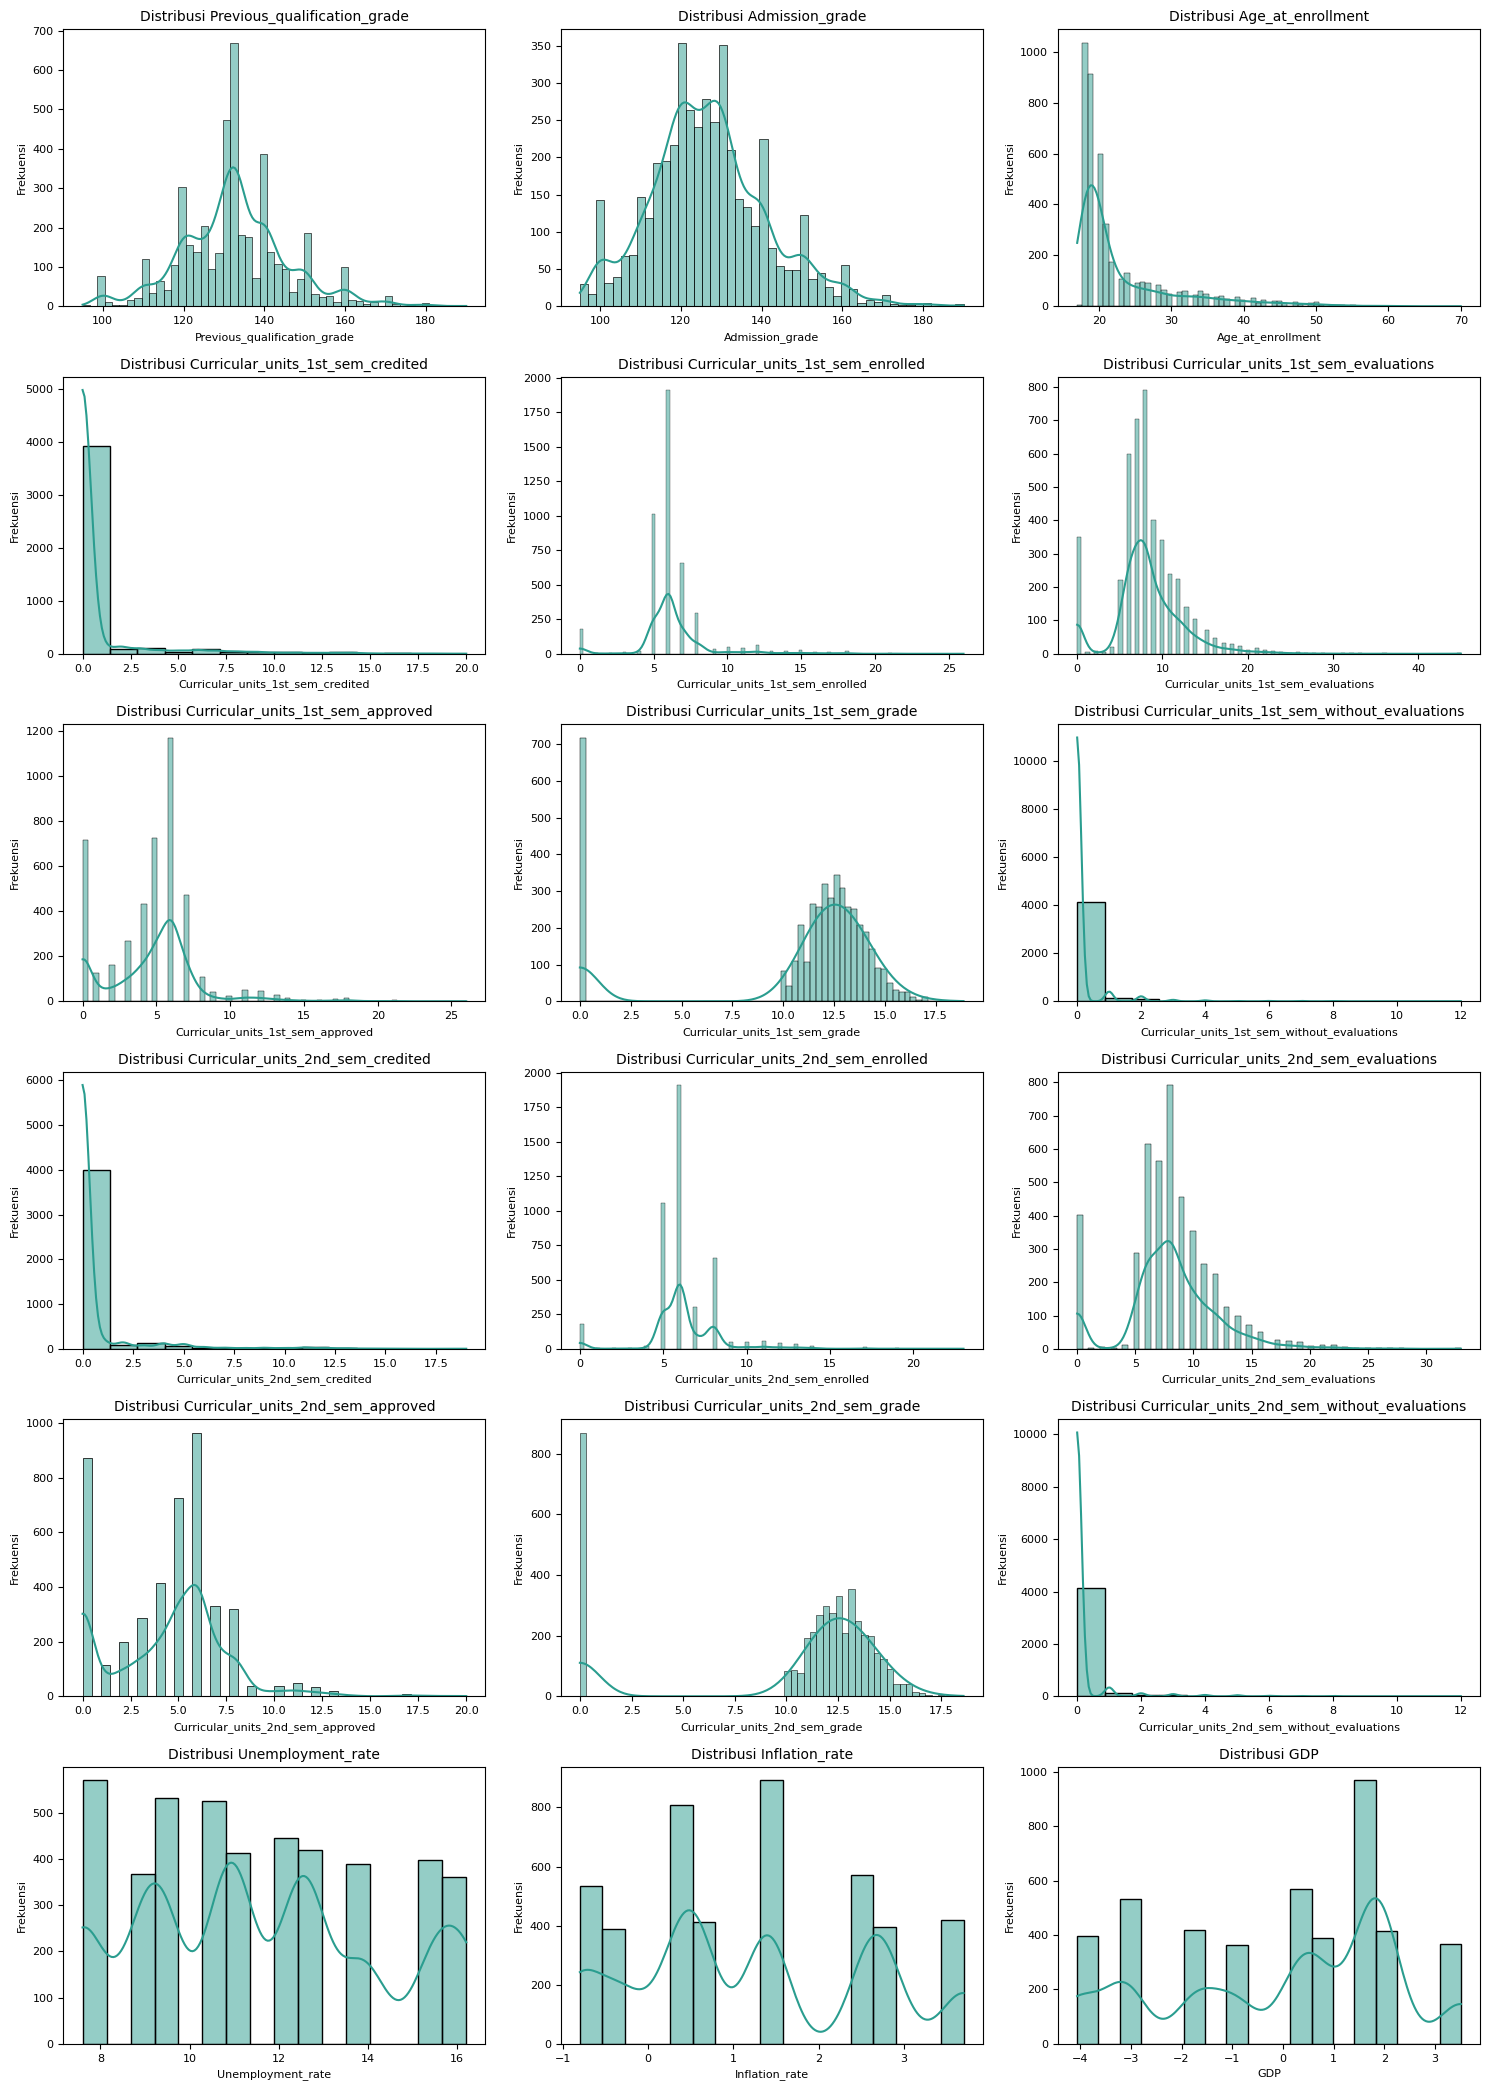

Fitur numerik yang diplot:
['Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP']


In [7]:
# Distribusi univariate fitur numerik dalam satu figure (subplot)
# Hindari kolom kategorik yang masih dikodekan sebagai angka.
categorical_code_cols = [
    "Marital_status",
    "Application_mode",
    "Application_order",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation",
    "Fathers_occupation",
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International",
    "Status",
    "is_dropout",
]

if "eda_categorical" in globals():
    categorical_code_cols = list(set(categorical_code_cols + eda_categorical))

numerical_cols = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in categorical_code_cols
]

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2a9d8f")
    axes[i].set_title(f"Distribusi {col}", fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("Frekuensi", fontsize=8)
    axes[i].tick_params(axis="both", labelsize=8)

for j in range(len(numerical_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print("Fitur numerik yang diplot:")
print(numerical_cols)

 Interpretasi Univariate Numerikal
- Distribusi `Admission_grade` dan `Previous_qualification_grade` cenderung unimodal (berpusat di rentang tengah), menandakan mayoritas nilai masuk pada rentang yang relatif serupa.
- `Age_at_enrollment` terlihat right-skewed: mayoritas mahasiswa masuk pada usia muda, dengan sebagian kecil pada usia yang lebih tinggi.
- Beberapa fitur akademik semester (`*_credited`, `*_without_evaluations`) terkonsentrasi di nilai rendah/0, sehingga distribusinya tidak normal dan memiliki ekor panjang.
- Variabel makro (`Unemployment_rate`, `Inflation_rate`, `GDP`) menunjukkan sebaran diskret pada level tertentu, mengindikasikan nilai diambil dari periode ekonomi tertentu.

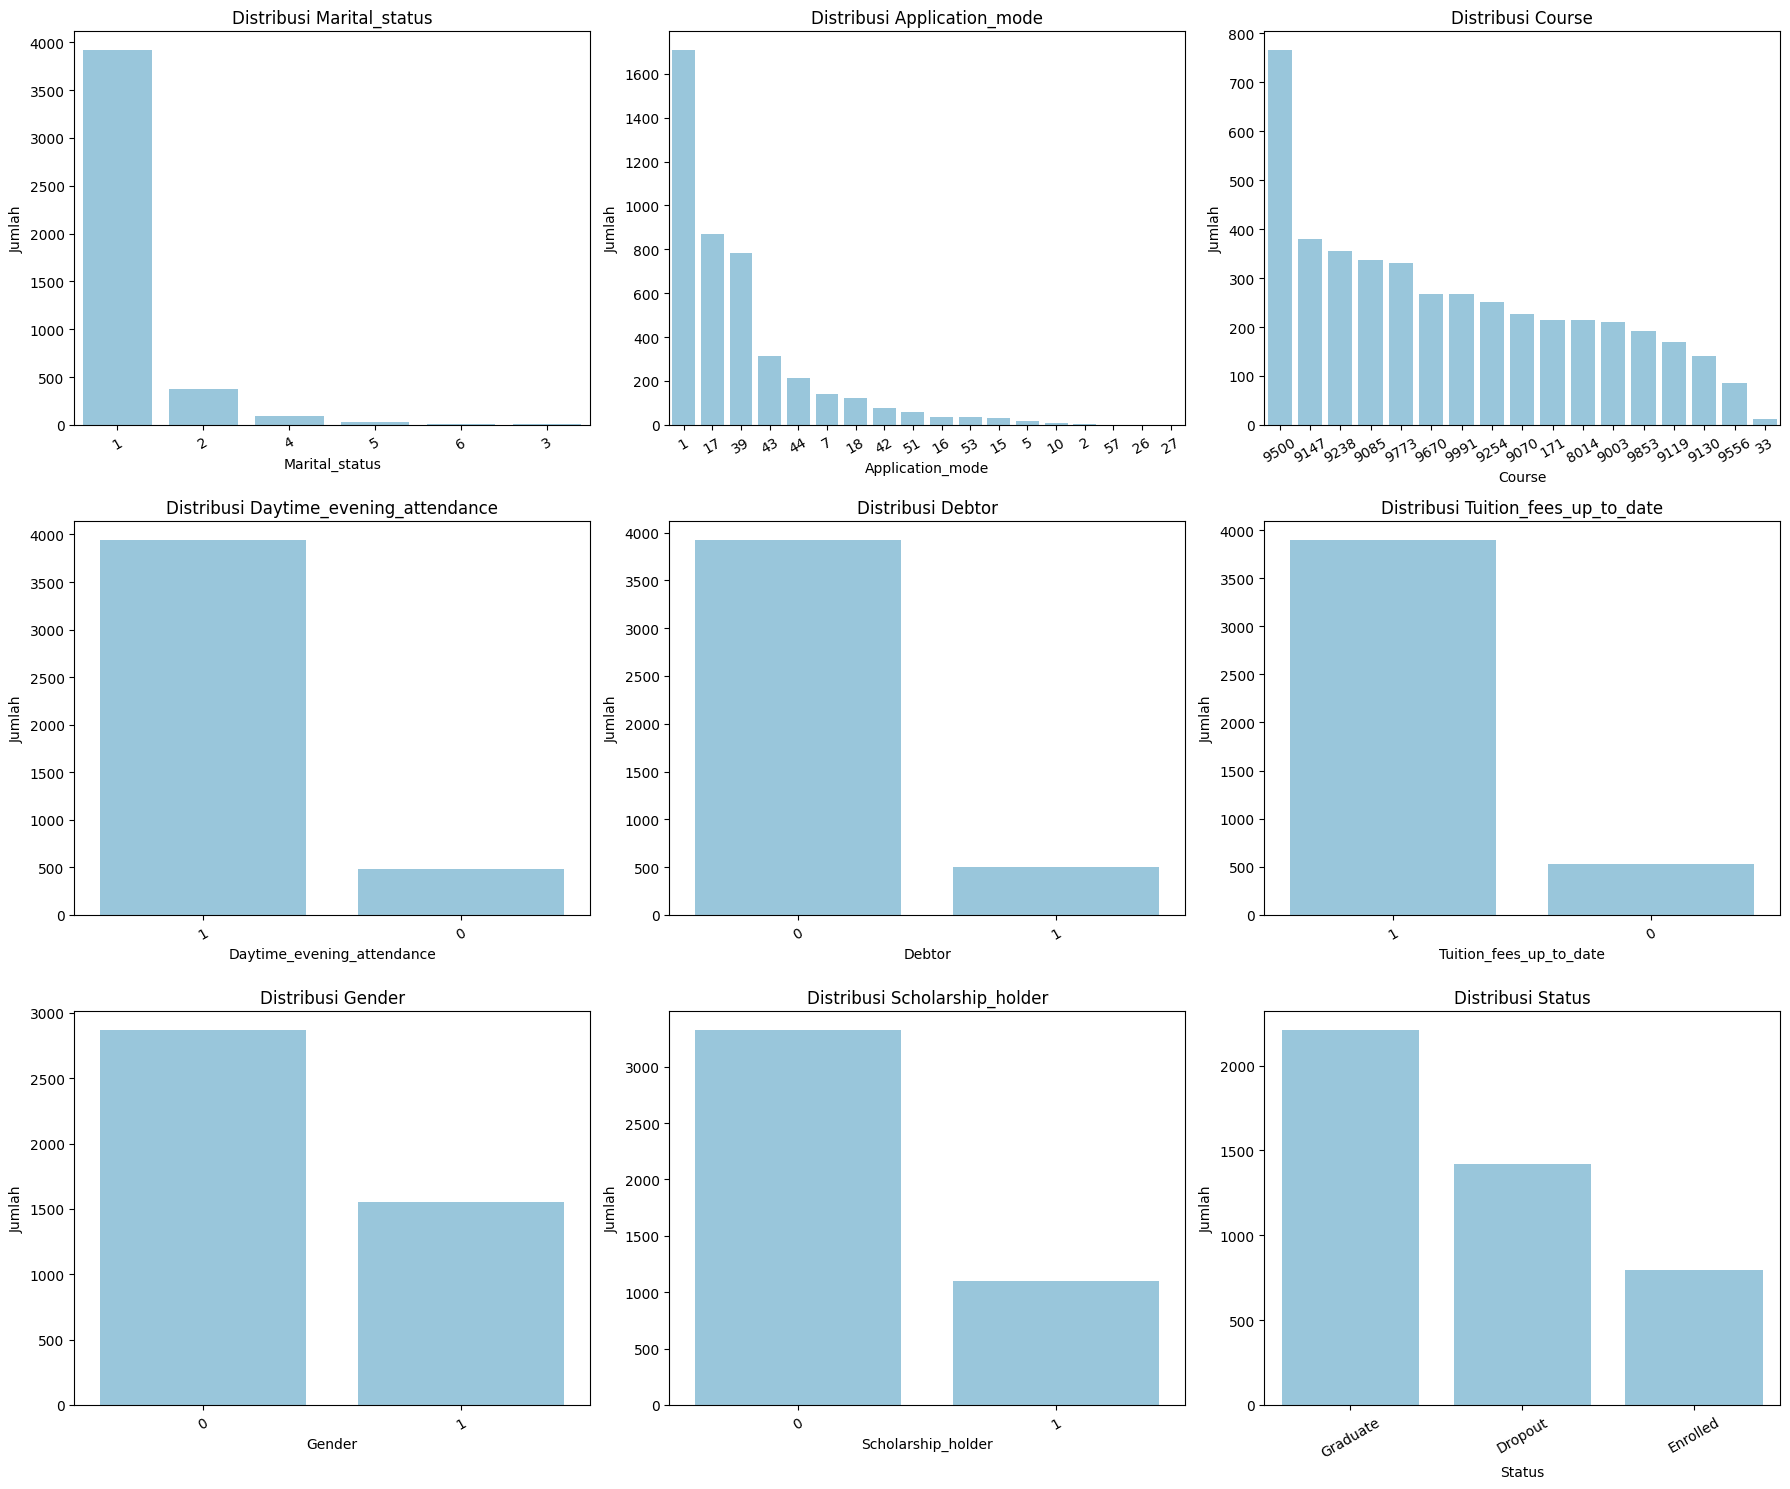


Marital_status
   Marital_status  count  percentage
0               1   3919       88.58
1               2    379        8.57
2               4     91        2.06
3               5     25        0.57
4               6      6        0.14
5               3      4        0.09

Application_mode
   Application_mode  count  percentage
0                 1   1708       38.61
1                17    872       19.71
2                39    785       17.74
3                43    312        7.05
4                44    213        4.81
5                 7    139        3.14
6                18    124        2.80
7                42     77        1.74
8                51     59        1.33
9                16     38        0.86

Course
   Course  count  percentage
0    9500    766       17.31
1    9147    380        8.59
2    9238    355        8.02
3    9085    337        7.62
4    9773    331        7.48
5    9670    268        6.06
6    9991    268        6.06
7    9254    252        5.70
8    9070

In [8]:
# Analisis univariate untuk fitur kategorik
categorical_cols = (
    eda_categorical
    if "eda_categorical" in globals()
    else df.select_dtypes(include=["object", "category"]).columns.tolist()
)
categorical_cols = [col for col in categorical_cols if col in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], color="#8ecae6")
    axes[i].set_title(f"Distribusi {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Jumlah")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(categorical_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Ringkasan proporsi tiap fitur kategorik
for col in categorical_cols:
    print(f"\n{col}")
    summary = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )
    summary["percentage"] = (summary["count"] / len(df) * 100).round(2)
    print(summary.head(10))

Interpretasi Univariate Kategorikal

- Komposisi `Status` menunjukkan kelas `Graduate` paling besar, diikuti `Dropout`, lalu `Enrolled`; ini menandakan target tidak sepenuhnya seimbang.
- Pada fitur biner seperti `Debtor`, `Scholarship_holder`, dan `Tuition_fees_up_to_date`, kelas mayoritas jauh lebih dominan dari kelas minoritas.
- Fitur `Course` dan `Application_mode` memiliki banyak kategori dengan frekuensi tidak merata (long-tail), sehingga encoding kategorikal perlu menangani kategori jarang.
- Secara umum, ketidakseimbangan kategori perlu diperhatikan agar model tidak bias ke kelas yang dominan.

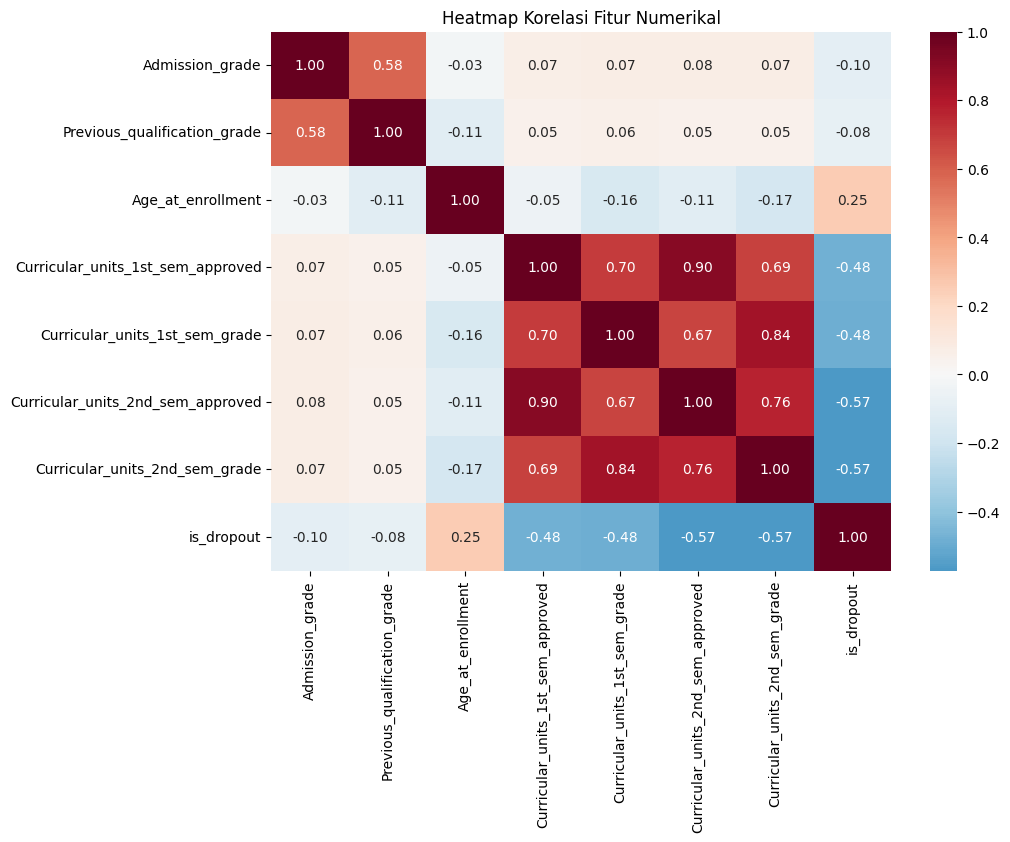

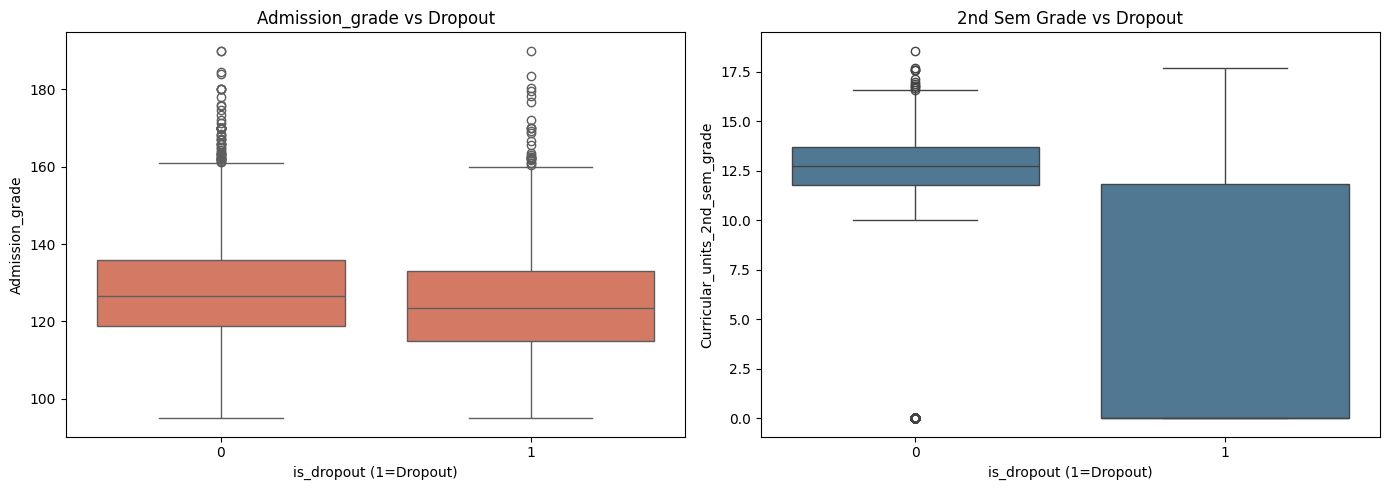

Dropout rate berdasarkan Tuition_fees_up_to_date (%):
   Tuition_fees_up_to_date  dropout_rate
0                        0     86.553030
1                        1     24.743326


In [9]:
# EDA Multivariate: Korelasi numerikal dan hubungan dengan target
if "is_dropout" not in df.columns:
    df["is_dropout"] = (df["Status"] == "Dropout").astype(int)

multivariate_numeric = [
    "Admission_grade",
    "Previous_qualification_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
    "is_dropout",
]

corr = df[multivariate_numeric].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Heatmap Korelasi Fitur Numerikal")
plt.show()

# Perbandingan distribusi fitur numerik terhadap dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="is_dropout", y="Admission_grade", ax=axes[0], color="#e76f51")
axes[0].set_title("Admission_grade vs Dropout")
axes[0].set_xlabel("is_dropout (1=Dropout)")

sns.boxplot(data=df, x="is_dropout", y="Curricular_units_2nd_sem_grade", ax=axes[1], color="#457b9d")
axes[1].set_title("2nd Sem Grade vs Dropout")
axes[1].set_xlabel("is_dropout (1=Dropout)")

plt.tight_layout()
plt.show()

# Dropout rate pada kategori penting
dropout_by_category = (
    df.groupby("Tuition_fees_up_to_date", as_index=False)["is_dropout"]
        .mean()
        .rename(columns={"is_dropout": "dropout_rate"})
)

dropout_by_category["dropout_rate"] = dropout_by_category["dropout_rate"] * 100
print("Dropout rate berdasarkan Tuition_fees_up_to_date (%):")
print(dropout_by_category)

Interpretasi Multivariat

- Heatmap menunjukkan fitur performa akademik semester memiliki korelasi negatif paling kuat terhadap `is_dropout`: semakin baik performa semester, kecenderungan dropout semakin rendah.
- `Age_at_enrollment` berkorelasi positif (lemah-sedang) dengan `is_dropout`, mengindikasikan mahasiswa yang masuk di usia lebih tinggi memiliki risiko dropout relatif lebih besar.
- Boxplot memperlihatkan median nilai (`Admission_grade` dan terutama `Curricular_units_2nd_sem_grade`) pada kelompok dropout cenderung lebih rendah.
- Dropout rate berdasarkan `Tuition_fees_up_to_date` memperlihatkan gap besar antara yang menunggak dan yang tidak, sehingga variabel ini penting sebagai sinyal risiko.

### Visualisasi Faktor Risiko Utama Dropout

Visualisasi berikut dibuat untuk menjawab temuan inti bahwa risiko dropout berkaitan dengan:
- indikator akademik semester awal,
- status administrasi biaya kuliah,
- indikator dukungan ekonomi seperti `Scholarship_holder`.

Grafik ini juga menjadi dasar bahwa model prediksi dapat digunakan sebagai alat screening awal mahasiswa berisiko.

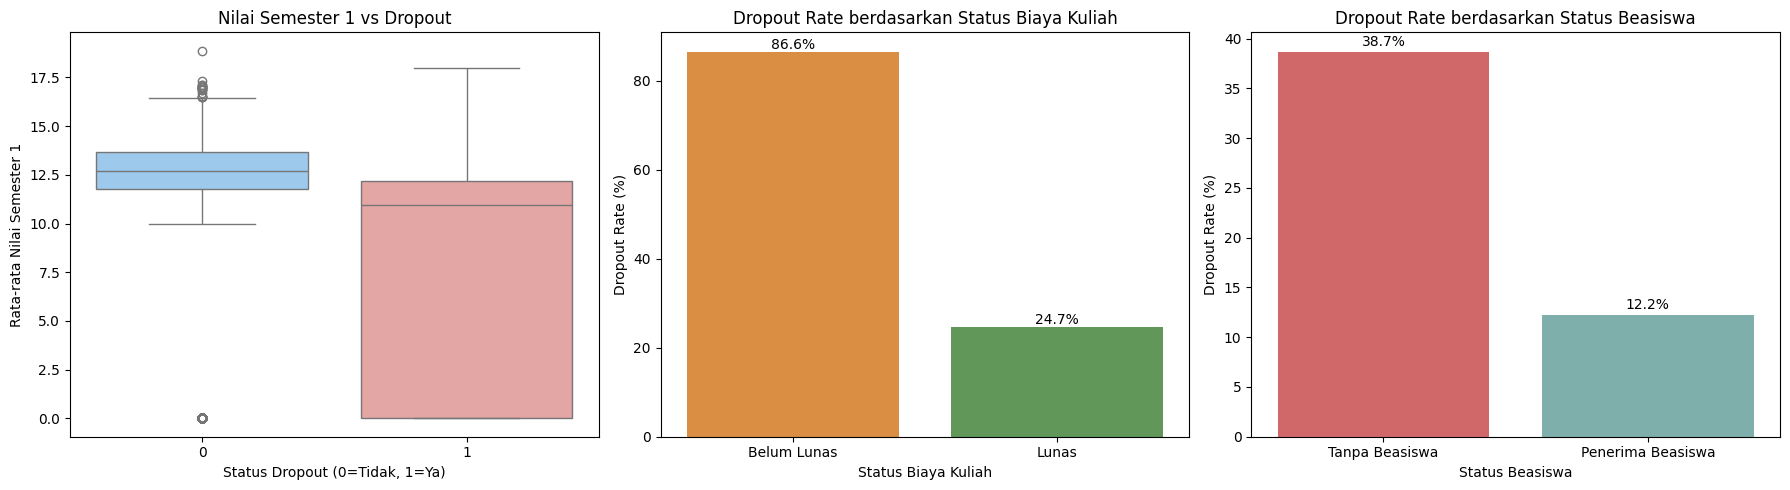

Ringkasan dropout rate (%):

Status biaya kuliah:
  Tuition_fees_up_to_date  dropout_rate_pct
0             Belum Lunas         86.553030
1                   Lunas         24.743326

Status beasiswa:
  Scholarship_holder  dropout_rate_pct
0     Tanpa Beasiswa         38.706767
1  Penerima Beasiswa         12.192903


In [10]:
# Visualisasi faktor utama yang berkaitan dengan dropout
if "is_dropout" not in df.columns:
    df["is_dropout"] = (df["Status"] == "Dropout").astype(int)

# Ringkasan dropout rate untuk faktor administrasi biaya dan dukungan ekonomi
dropout_tuition = (
    df.groupby("Tuition_fees_up_to_date", as_index=False)["is_dropout"]
      .mean()
      .assign(dropout_rate_pct=lambda x: x["is_dropout"] * 100)
      .replace({"Tuition_fees_up_to_date": {0: "Belum Lunas", 1: "Lunas"}})
)

dropout_scholarship = (
    df.groupby("Scholarship_holder", as_index=False)["is_dropout"]
      .mean()
      .assign(dropout_rate_pct=lambda x: x["is_dropout"] * 100)
      .replace({"Scholarship_holder": {0: "Tanpa Beasiswa", 1: "Penerima Beasiswa"}})
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Indikator akademik semester awal vs dropout
sns.boxplot(
    data=df,
    x="is_dropout",
    y="Curricular_units_1st_sem_grade",
    hue="is_dropout",
    dodge=False,
    legend=False,
    ax=axes[0],
    palette=["#90caf9", "#ef9a9a"],
)
axes[0].set_title("Nilai Semester 1 vs Dropout")
axes[0].set_xlabel("Status Dropout (0=Tidak, 1=Ya)")
axes[0].set_ylabel("Rata-rata Nilai Semester 1")

# 2) Status administrasi biaya kuliah
sns.barplot(
    data=dropout_tuition,
    x="Tuition_fees_up_to_date",
    y="dropout_rate_pct",
    hue="Tuition_fees_up_to_date",
    dodge=False,
    legend=False,
    ax=axes[1],
    palette=["#f28e2b", "#59a14f"],
)
axes[1].set_title("Dropout Rate berdasarkan Status Biaya Kuliah")
axes[1].set_xlabel("Status Biaya Kuliah")
axes[1].set_ylabel("Dropout Rate (%)")
for i, value in enumerate(dropout_tuition["dropout_rate_pct"]):
    axes[1].text(i, value + 0.6, f"{value:.1f}%", ha="center", fontsize=10)

# 3) Indikator dukungan ekonomi (scholarship holder)
sns.barplot(
    data=dropout_scholarship,
    x="Scholarship_holder",
    y="dropout_rate_pct",
    hue="Scholarship_holder",
    dodge=False,
    legend=False,
    ax=axes[2],
    palette=["#e15759", "#76b7b2"],
)
axes[2].set_title("Dropout Rate berdasarkan Status Beasiswa")
axes[2].set_xlabel("Status Beasiswa")
axes[2].set_ylabel("Dropout Rate (%)")
for i, value in enumerate(dropout_scholarship["dropout_rate_pct"]):
    axes[2].text(i, value + 0.6, f"{value:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Ringkasan dropout rate (%):")
print("\nStatus biaya kuliah:")
print(dropout_tuition[["Tuition_fees_up_to_date", "dropout_rate_pct"]])
print("\nStatus beasiswa:")
print(dropout_scholarship[["Scholarship_holder", "dropout_rate_pct"]])

Interpretasi Visualisasi Faktor Risiko Utama

- Grafik akademik menunjukkan mahasiswa dengan performa semester awal lebih rendah cenderung berada pada kelompok dropout.
- Grafik administrasi biaya menunjukkan perbedaan dropout rate yang jelas antara mahasiswa yang lunas dan belum lunas.
- Grafik scholarship holder menunjukkan dukungan ekonomi (status beasiswa) berkaitan dengan perbedaan risiko dropout.

Kesimpulan tahap Data Understanding: ketiga faktor tersebut dapat dijadikan sinyal risiko untuk screening awal sebelum kondisi mahasiswa memburuk.

## Data Preparation / Preprocessing

> Pada tahap ini data disiapkan menjadi format yang dapat dipahami model machine learning.

Langkah yang dilakukan:
- Menyaring data agar **hanya berisi status final**: `Dropout` dan `Graduate`.
- Data `Enrolled` tidak dipakai untuk training karena belum memiliki label akhir.
- Membuat target biner `is_dropout` dari kolom `Status` pada data hasil filter.
- Menentukan fitur yang akan dipakai untuk prediksi.
- Memisahkan fitur kategorikal untuk proses encoding.
- Membagi data menjadi train set dan test set dengan stratifikasi target agar proporsi kelas tetap terjaga.

Output:
- `X_train`, `X_test`, `y_train`, dan `y_test` siap untuk proses modeling dengan target yang valid (Dropout vs Graduate).

Shape data mentah:

 (4424, 38)

Missing values:
 Marital_status                  0
Application_mode                0
Application_order               0
Course                          0
Daytime_evening_attendance      0
Previous_qualification          0
Previous_qualification_grade    0
Nacionality                     0
Mothers_qualification           0
Fathers_qualification           0
dtype: int64

Status distribution (raw):
 Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


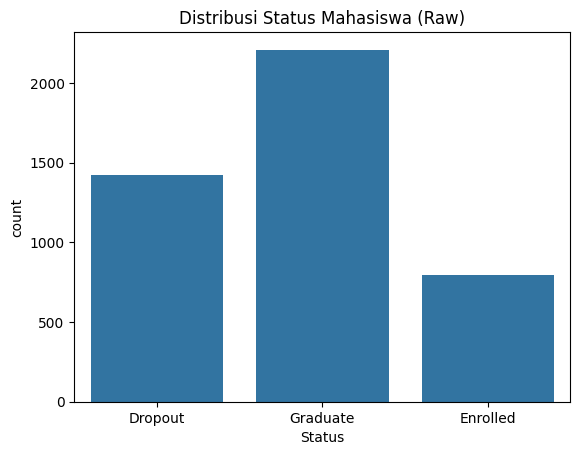


Shape data latih (Dropout + Graduate): (3630, 38)

Status distribution (training):
 Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


((2904, 15), (726, 15))

In [15]:
print("Shape data mentah:", df.shape)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False).head(10))
print("\nStatus distribution (raw):\n", df["Status"].value_counts())

sns.countplot(data=df, x="Status")
plt.title("Distribusi Status Mahasiswa (Raw)")
plt.show()

# Gunakan hanya label final untuk training model
train_df = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
train_df["is_dropout"] = (train_df["Status"] == "Dropout").astype(int)

print("\nShape data latih (Dropout + Graduate):", train_df.shape)
print("\nStatus distribution (training):\n", train_df["Status"].value_counts())

feature_columns = [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification_grade",
    "Admission_grade",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade",
]

categorical_columns = [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
]

X = train_df[feature_columns]
y = train_df["is_dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

## Modeling

> Tahap modeling membangun pipeline terintegrasi antara preprocessing dan algoritma klasifikasi.

Strategi model:
- `OneHotEncoder` untuk fitur kategorikal dengan `handle_unknown="ignore"`.
- `ColumnTransformer` untuk menggabungkan transformasi kategorikal dan fitur numerikal.
- `LogisticRegression` sebagai baseline model dengan `class_weight="balanced"` agar lebih adaptif pada ketidakseimbangan kelas.

Output:
- Model terlatih dan prediksi pada data uji (`y_pred` dan `y_prob`).

In [16]:
# Preprocessing pipeline untuk fitur kategorikal
preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns,
        )
    ],
    remainder="passthrough",
)

# Pipeline lengkap dengan preprocessing dan model klasifikasi
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced")),
    ]
)
# Latih model dan evaluasi pada data test
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Training selesai.")

Training selesai.


## Evaluation

> Evaluasi digunakan untuk menilai seberapa baik model membedakan mahasiswa dropout dan non-dropout.

Metrik yang dipakai:
- Accuracy: ketepatan prediksi secara umum.
- Precision: ketepatan saat model memprediksi dropout.
- Recall: kemampuan menangkap kasus dropout aktual.
- F1-score: keseimbangan precision dan recall.
- ROC-AUC: kemampuan model memisahkan dua kelas pada berbagai threshold.

Visual evaluasi:
- Confusion Matrix untuk melihat distribusi prediksi benar/salah per kelas.

Output:
- Dasar kuantitatif untuk menilai kelayakan model sebagai sistem early warning.

Metrics:
- accuracy: 0.9063
- precision: 0.8600
- recall: 0.9085
- f1: 0.8836
- roc_auc: 0.9569

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       442
           1       0.86      0.91      0.88       284

    accuracy                           0.91       726
   macro avg       0.90      0.91      0.90       726
weighted avg       0.91      0.91      0.91       726



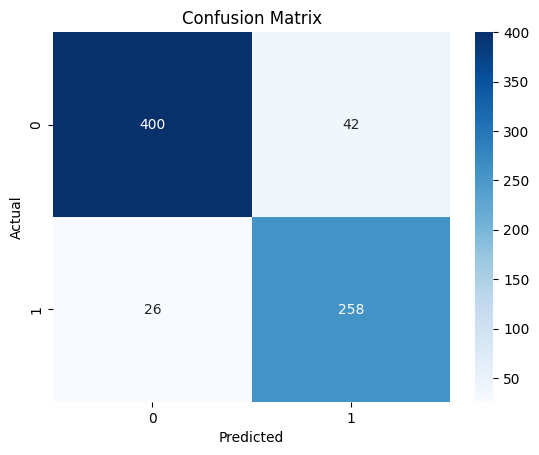

In [17]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

print("Metrics:")
for key, value in metrics.items():
    print(f"- {key}: {value:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# Feature importance dari Logistic Regression (berdasarkan besar absolut koefisien)
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_.ravel()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients),
}).sort_values("abs_coefficient", ascending=False)

top_features = importance_df.head(10).copy()
print("Top 10 feature importance (abs coefficient):")
print(top_features[["feature", "coefficient", "abs_coefficient"]].to_string(index=False))

Top 10 feature importance (abs coefficient):
                       feature  coefficient  abs_coefficient
               cat__Course_171    -3.648543         3.648543
      cat__Application_mode_15    -1.490621         1.490621
              cat__Course_9853     1.409820         1.409820
              cat__Course_9119     1.371228         1.371228
cat__Tuition_fees_up_to_date_0     1.242518         1.242518
cat__Tuition_fees_up_to_date_1    -1.234670         1.234670
      cat__Application_mode_26     1.115762         1.115762
      cat__Application_mode_42     1.055540         1.055540
      cat__Application_mode_16    -0.866419         0.866419
              cat__Course_9238    -0.794594         0.794594


## Kesimpulan Akhir

### 1) Kesimpulan Faktor dan Karakteristik Dropout (EDA + Dashboard)
- Risiko dropout berkaitan kuat dengan performa akademik awal, terutama nilai dan jumlah mata kuliah lulus pada semester 1 dan semester 2.
- Faktor administratif/finansial juga menonjol: mahasiswa dengan status `Tuition_fees_up_to_date = 0` memiliki risiko dropout lebih tinggi.
- Dukungan ekonomi melalui beasiswa berkaitan dengan perbedaan tingkat risiko, sehingga intervensi non-akademik tetap penting selain pembinaan akademik.

### 2) Kesimpulan Performa Model (Kuantitatif) dan Fitur Penting
Model Logistic Regression dilatih pada data berlabel final saja (`Dropout` vs `Graduate`), sedangkan `Enrolled` tidak digunakan untuk training.

Metrik evaluasi pada test set:
- Accuracy: **0.9063**
- Precision: **0.8600**
- Recall: **0.9085**
- F1-score: **0.8836**
- ROC-AUC: **0.9569**

Fitur paling berpengaruh (berdasarkan absolut koefisien) didominasi oleh:
- Kelompok fitur `Course` (misalnya `Course_171`, `Course_9853`, `Course_9119`).
- Kelompok fitur `Application_mode` (misalnya `Application_mode_15`, `Application_mode_26`, `Application_mode_42`).
- Status pembayaran kuliah (`Tuition_fees_up_to_date_0` dan `Tuition_fees_up_to_date_1`).

Kesimpulan: model sudah cukup baik sebagai sistem *early warning*, namun tetap sebaiknya dipakai sebagai alat bantu keputusan, bukan satu-satunya dasar keputusan akhir.

### Insight Bisnis untuk Jaya Jaya Institut

- Tingginya dropout adalah risiko strategis karena berdampak pada reputasi institusi, efisiensi operasional akademik, dan keberlanjutan jumlah lulusan.
- Faktor akademik semester awal adalah sinyal dini terkuat, sehingga monitoring nilai dan kelulusan mata kuliah di tahun pertama perlu diprioritaskan.
- Faktor administratif/finansial (`Tuition_fees_up_to_date`) dan dukungan ekonomi (`Scholarship_holder`) perlu digabung dalam strategi retensi agar intervensi lebih menyeluruh.

### Rekomendasi Aksi Bisnis

- Terapkan sistem early warning berbasis skor risiko dropout pada awal dan pertengahan semester.
- Prioritaskan mentoring akademik untuk mahasiswa dengan performa rendah di semester 1 dan 2.
- Aktifkan follow-up finansial untuk mahasiswa dengan status pembayaran tertunda.
- Perluas skema beasiswa atau bantuan biaya untuk kelompok berisiko tinggi.
- Lakukan evaluasi berkala atas precision-recall model agar threshold intervensi tetap sesuai kebutuhan bisnis.